# Лаба 1.04

### Математические функции и XML

In [17]:
import sys; sys.path.insert(0, '../')
from meas import *
from meas.DirectMultipleMeasurement import DirectMultipleMeasurement as DMM

from math import *
from pprint import pprint
from lxml import etree              

# Парсим XML
dom = etree.parse('latex4.xml')
xml = dom.getroot()
next = lambda x: x.pop(0).text

### Результаты измерений

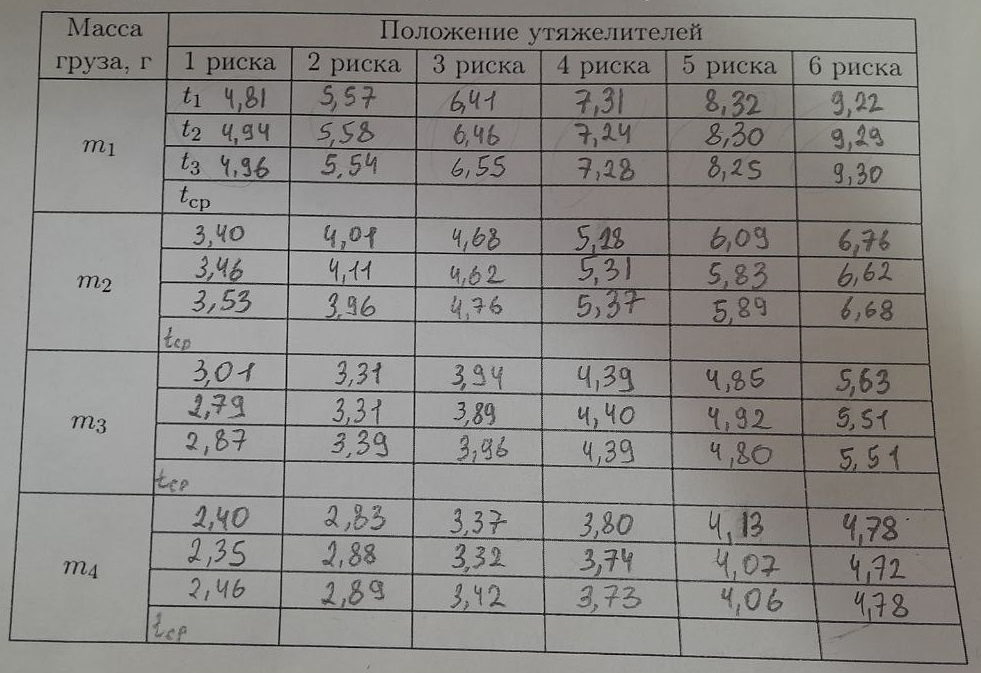

In [18]:
# Инструментальные погрешности
delta_t = 0.01   # c

# Таблица [столбец-риски][строка-массы]

direct = {
    1: [DMM([4.81, 4.94, 4.96], delta_t), DMM([3.40, 3.46, 3.53], delta_t), DMM([3.01, 2.79, 2.87], delta_t), DMM([2.40, 2.35, 2.46], delta_t)],
    2: [DMM([5.57, 5.58, 5.54], delta_t), DMM([4.01, 4.11, 3.96], delta_t), DMM([3.31, 3.31, 3.39], delta_t), DMM([2.83, 2.88, 2.89], delta_t)],
    3: [DMM([6.41, 6.46, 6.55], delta_t), DMM([4.68, 4.62, 4.76], delta_t), DMM([3.94, 3.89, 3.96], delta_t), DMM([3.37, 3.32, 3.42], delta_t)],
    4: [DMM([7.31, 7.24, 7.28], delta_t), DMM([5.28, 5.31, 5.37], delta_t), DMM([4.39, 4.40, 4.39], delta_t), DMM([3.80, 3.74, 3.73], delta_t)],
    5: [DMM([8.32, 8.30, 8.25], delta_t), DMM([6.09, 5.83, 5.89], delta_t), DMM([4.85, 4.92, 4.80], delta_t), DMM([4.13, 4.07, 4.06], delta_t)],
    6: [DMM([9.22, 9.29, 9.30], delta_t), DMM([6.76, 6.62, 6.68], delta_t), DMM([5.63, 5.51, 5.51], delta_t), DMM([4.78, 4.72, 4.78], delta_t)]
}


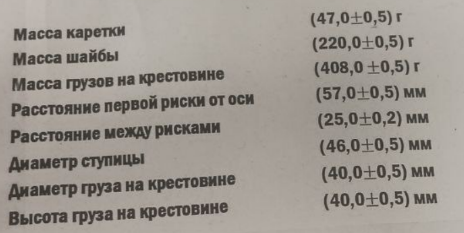

In [19]:
# Масса каретки
direct_m_carriage = Measurement(
    47.0, 0.5, dim=0.001, direct=True,
    name='m каретки', char='m_\\text{каретки}', unit='\\text{кг}')

# Масса шайбы
direct_m_puck = Measurement(
    220.0, 0.5, dim=0.001, direct=True,
    name='m шайбы', char='m_\\text{шайбы}', unit='\\text{кг}')

# Масса грузов на крестовине
direct_m_cargo = Measurement(
    408.0, 0.5, dim=0.001, direct=True,
    name='m гр', char='m_\\text{гр}', unit='\\text{кг}')

# Расстояние первой риски от оси
direct_l_1 = Measurement(
    57.0, 0.5, dim=0.001, direct=True,
    name='l1', char='l_1', unit='\\text{м}')

# Расстояние между рисками
direct_l_0 = Measurement(
    25.0, 0.5, dim=0.001, direct=True,
    name='l0', char='l_0', unit='\\text{м}')

# Диаметр ступицы
direct_d_stup = Measurement(
    46.0, 0.5, dim=0.001, direct=True,
    name='d ступицы', char='d_\\text{ступицы}', unit='\\text{м}')

# Высота и диаметр груза
direct_b = Measurement(
    40.0, 0.5, dim=0.001, direct=True,
    name='b', char='b', unit='\\text{м}')

# Высота подъёма каретки с шайбами
direct_h = Measurement(
    700.0, 1.0, dim=0.001, direct=True,
    name='h', char='h', unit='\\text{м}')

# Ускорение свободного падения
g = 9.8195

In [20]:
print(direct_h)

0.7000±0.0010, ε = 0.14% (0.7, Δ = 0.001000000, ε = 0.142857143)


### Задания

1. Найти среднее время падения гири для всех масс гири и всех
положениях утяжелителей на крестовине. Для первого значения 𝑡ср
рассчитать погрешность среднего значения времени ∆𝑡.

In [21]:
xdt = xml.findall("dt")
# pprint([x.text for x in xdt])
table = next(xdt)


for m in range(4):
    for i in range(3):
        for risk in direct.keys():
            table += f'{direct[risk][m].measurments[i].value:.2f}'
            table += next(xdt)
    for risk in direct.keys():
        table += f'{direct[risk][m].value:.2f}'
        table += next(xdt)

print(table)
print(direct[1][0].DDM())
delta_t_new = 0.2


\begin{table}[ht]
\centering
\caption{Протокол измерений времени падения груза при разной массе груза и разном положении утяжелителей на крестовине}
\label{tab:direct104}
\begin{tabular}{|c|c|c|c|c|c|c|c|}
\hline
\multirow{2}{*}{\textbf{Масса}} & 
\multirow{2}{*}{\textbf{Время}} & 
\multicolumn{6}{c|}{\textbf{Положение утяжелителей}} \\ \cline{3-8}
& & 1 риска & 2 риска & 3 риска & 4 риска & 5 риска & 6 риска \\ \hline
\multirow{4}{*}{\( m_1 \)} 
& \( t_1 \) & 4.81 & 5.57 & 6.41 & 7.31 & 8.32 & 9.22 \\ \cline{2-8}
& \( t_2 \) & 4.94 & 5.58 & 6.46 & 7.24 & 8.30 & 9.29 \\ \cline{2-8}
& \( t_3 \) & 4.96 & 5.54 & 6.55 & 7.28 & 8.25 & 9.30 \\ \cline{2-8}
& \( t_{\text{ср}} \) & 4.90 & 5.56 & 6.47 & 7.28 & 8.29 & 9.27 \\ \hline
\multirow{4}{*}{\( m_2 \)} 
& \( t_1 \) & 3.40 & 4.01 & 4.68 & 5.28 & 6.09 & 6.76 \\ \cline{2-8}
& \( t_2 \) & 3.46 & 4.11 & 4.62 & 5.31 & 5.83 & 6.62 \\ \cline{2-8}
& \( t_3 \) & 3.53 & 3.96 & 4.76 & 5.37 & 5.89 & 6.68 \\ \cline{2-8}
& \( t_{\text{ср}} \) & 3.46 & 4

2. Используя найденные значения $t_{ср}$ рассчитать ускорение $a$ груза, угловое ускорение $𝜀$ крестовины и момент $𝑀$ силы натяжения
нити. Результаты оформить в виде таблицы. Для первых значений
$𝑎$, $𝜀$ и $𝑀$ вычислить их погрешности и записать соответствующие
доверительные интервалы.

$m = m_\text{каретки} + n \cdot m_\text{шайбы}$

$a = \frac{2h}{t^2}$

$\varepsilon = \frac{2a}{d_\text{ступицы}}$

$M = \frac{m d_\text{ступицы}}{2}(g - a)$

In [22]:
indirect_a = {}
indirect_E = {}
indirect_M = {}
indirect_m = []

# direct: g, h, d_stup
# indirect: m, a, E, M 
for n in range(4):
    m = Measurement(
        direct_m_carriage.value_ + direct_m_puck.value_ * (n + 1),
        sqrt((direct_m_carriage.delta_)**2 + ((n + 1)*direct_m_puck.delta_)**2)
    )
    indirect_m.append(m)
    for risk in direct.keys():
        a = Measurement(
            2 * direct_h.value_ / direct[risk][n].value_**2, 
            epsilon=sqrt((direct_h.delta_/direct_h.value_)**2 + (2*delta_t_new/direct[1][0].value_)**2)
        )
        E = Measurement(
            2 * a.value_ / direct_d_stup.value_, 
            epsilon=sqrt((direct_h.delta_/direct_h.value_)**2 + (2*delta_t_new/direct[1][0].value_)**2)
        )
        M = Measurement(
            m.value_ * direct_d_stup.value_ * (g - a.value_) / 2,
            epsilon=sqrt((m.delta_/m.value_)**2 + (direct_d_stup.delta_/direct_d_stup.value_)**2 + (a.delta_/(g-a.value_))**2)
        )
        indirect_a.setdefault(risk, [None]*4)[n] = a
        indirect_E.setdefault(risk, [None]*4)[n] = E
        indirect_M.setdefault(risk, [None]*4)[n] = M
        
# pprint(indirect_a)
print("delta", indirect_m[0].delta, indirect_a[1][0].delta, indirect_E[1][0].delta, indirect_M[1][0].delta)
print("epsilon", indirect_m[0].epsilon, indirect_a[1][0].epsilon, indirect_E[1][0].epsilon, indirect_M[1][0].epsilon)

delta 0.0007 5e-05 0.0021 7e-06
epsilon 0.26 0.08 0.08 0.011


In [23]:
err = xml.findall("err1")
text = next(err) + str(indirect_m[0].value) + next(err) + str(indirect_m[0].delta) + next(err) + str(indirect_m[0].epsilon) + next(err)
text += str(indirect_a[1][0].value) + next(err) + str(indirect_a[1][0].epsilon) + next(err) + str(indirect_a[1][0].delta) + next(err)
text += str(indirect_E[1][0].value) + next(err) + str(indirect_E[1][0].epsilon) + next(err) + str(indirect_E[1][0].delta) + next(err)
text += str(indirect_M[1][0].value) + next(err) + str(indirect_M[1][0].epsilon) + next(err) + str(indirect_M[1][0].delta) + next(err)
print(text)


Для массы спускающегося груза: $m = m_\text{каретки} + n \cdot m_\text{шайбы} = 0.267 \text{кг}$

\centerline{$\Delta_m = \sqrt{(\Delta_{m_\text{каретки}})^2 + (n \cdot \Delta_{m_\text{шайбы}})^2} = 0.0007 \text{кг}, \quad \varepsilon_{m} = \frac{\Delta_m}{m} \cdot 100\% = 0.26\%$.}

Для ускорения: $a=\frac{2h}{t^2} = 0.05823 \text{м}/\text{с}^2$, 

\centerline{$\varepsilon_{a} = \sqrt{(\frac{2}{3} \cdot \frac{\Delta h}{h})^2 + (\frac{\Delta t}{t})^2} \cdot 100\% = 0.08\%, \quad \Delta_a=\frac{a \cdot \varepsilon_a}{100\%} = 5e-05 \text{м}/\text{с}^2$.}

Для углового ускорения: $\varepsilon=\frac{2a}{d_\text{ступ}} = 2.5317 \text{рад}/\text{с}^2$, 

\centerline{$\varepsilon_{\varepsilon} = \sqrt{(\frac{\Delta a}{a})^2 + (\frac{2}{3} \cdot \frac{\Delta d_\text{ступ}}{d_\text{ступ}})^2} \cdot 100\% = 0.08\%, \quad \Delta_\varepsilon=\frac{\varepsilon \cdot \varepsilon_\varepsilon}{100\%} = 0.0021 \text{рад}/\text{с}^2$.}

Для момента силы натяжения нити: $M=\frac{md_\text{ступ}}{2}(g-a)

In [24]:
xdt2 = xml.findall("dtx")
# pprint([x.text for x in xdt2])
table2 = next(xdt2)

for n in range(4):
    table2 += f"{indirect_m[n].value:.4f}"
    table2 += next(xdt2)
    for risk in direct.keys():
        table2 += f"{indirect_a[risk][n].value:.5f}"
        table2 += next(xdt2)
    for risk in direct.keys():
        table2 += f"{indirect_E[risk][n].value:.4f}"
        table2 += next(xdt2)
    for risk in direct.keys():
        table2 += f"{indirect_M[risk][n].value:.6f}"
        table2 += next(xdt2)
        
print(table2)


\begin{table}[h]
\centering
\caption{Ускорение, угловое ускорение и момент силы.}
\label{tab:direct104}
\begin{tabular}{|c|c|c|c|c|c|c|c|}
\hline
\multirow{3}{*}{\textbf{Значение}} & 
\multirow{3}{*}{$m$, кг} & 
\multicolumn{6}{c|}{\textbf{Положение утяжелителей}} \\ \cline{3-8}
& & 1 риска & 2 риска & 3 риска & 4 риска & 5 риска & 6 риска \\ \hline
$a, \text{м}/\text{с}^2$ & \multirow{3}{*}{0.2670} & 0.05823 & 0.04523 & 0.03341 & 0.02644 & 0.02037 & 0.01629 \\ \cline{1-1} \cline{3-8}
$\varepsilon, \text{рад}/\text{с}^2$ & & 2.5317 & 1.9667 & 1.4526 & 1.1496 & 0.8857 & 0.7083 \\ \cline{1-1} \cline{3-8}
$M, \text{Н}\cdot\text{м}$ & & 0.059944 & 0.060024 & 0.060096 & 0.060139 & 0.060176 & 0.060202 \\ \hline
$a, \text{м}/\text{с}^2$ & \multirow{3}{*}{0.4870} & 0.11670 & 0.08634 & 0.06374 & 0.04947 & 0.03972 & 0.03131 \\ \cline{1-1} \cline{3-8}
$\varepsilon, \text{рад}/\text{с}^2$ & & 5.0750 & 3.7541 & 2.7712 & 2.1507 & 1.7271 & 1.3614 \\ \cline{1-1} \cline{3-8}
$M, \text{Н}\cdot\text{м}$

3. Для каждого положения утяжелителей на крестовине в координатах 𝑀 (ордината) – 𝜀 (абсцисса) на одном рисунке нанести точки
найденных зависимостей 𝑀(𝜀). Отметить значения погрешностей ∆𝜀 и ∆𝑀, вычисленные в п. 2, у тех точек, для которых они найдены.

4. Для каждого положения утяжелителей на основе таблицы 𝑀
и 𝜀 по методу наименьших квадратов (МНК) рассчитать момент 𝐼
инерции крестовины с утяжелителями и момент силы трения 𝑀тр.
Из формулы (6) следует, что теоретическая связь между моментом
силы натяжения нити и угловым ускорением крестовины описывается уравнением
𝑀 = 𝑀тр + 𝐼𝜀, (8)
т.е. зависимость 𝑀(𝜀) является линейной, а величины 𝐼 и 𝑀тр – коэффициенты этой зависимости.

5. Используя вычисленные в п. 4 значения 𝐼 и 𝑀тр , на том же
рисунке , что и точки п. 3.,построить графики зависимости (8) для
всех положений утяжелителей.

Время выполнения = 0:00:00
Время выполнения = 0:00:00
Время выполнения = 0:00:00
Время выполнения = 0:00:00
Время выполнения = 0:00:00
Время выполнения = 0:00:00


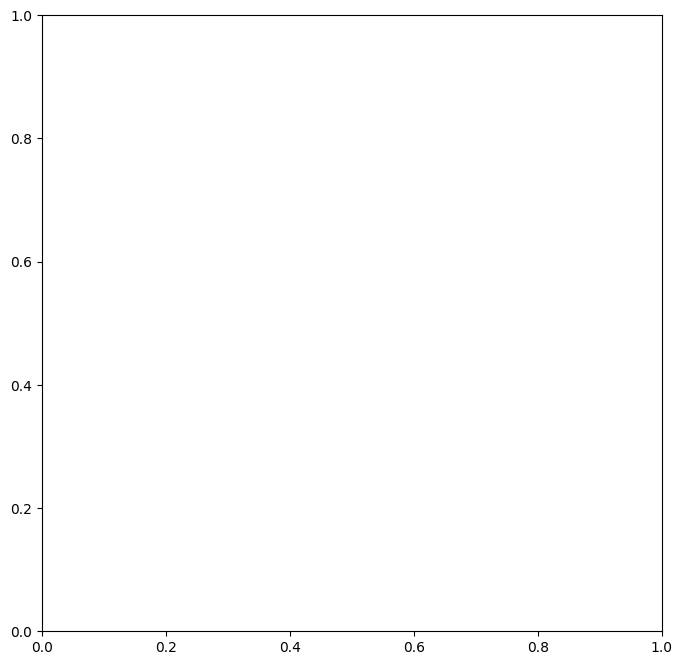

In [25]:
M_E = [LinearMultipleMeasurement(indirect_E[risk], indirect_M[risk]) for risk in direct.keys()]  

Drawer().plot_multiple_dependency(M_E,
    labels=["1 риска", "2 риски", "3 риски", "4 риски", "5 рисок", "6 рисок"],
    x_name="ε", x_unit="рад/с²", y_name="M", y_unit="H⋅м",
    error_X=True, error_Y=True,
    )

In [26]:
mex = xml.findall("me")
text = next(mex)
indirect_M_tr, indirect_I = {}, {}
for risk, m_e in zip(direct.keys(), M_E):
    indirect_M_tr[risk] = m_e.a
    indirect_I[risk] = m_e.b
    text += str(m_e.a.value) + next(mex) + str(m_e.b.value) + next(mex)
for m_e in M_E:
    text += str(m_e.b.value) + next(mex)
for m_e in M_E:
    text += str(m_e.a.value) + next(mex)
print(text)

print(M_E[0].a, M_E[0].b)


\begin{itemize}
    \item Для 1 риски: $M = 0.017+0.0182 \cdot I$.
    \item Для 2 рисок: $M = 0.008+0.0269 \cdot I$.
    \item Для 3 рисок: $M = 0.006+0.0379 \cdot I$.
    \item Для 4 рисок: $M = 0.008+0.0467 \cdot I$.
    \item Для 5 рисок: $M = 0.016+0.054 \cdot I$.
    \item Для 6 рисок: $M = 0.008+0.0752 \cdot I$.
\end{itemize}

\begin{table}[H]
\centering
\caption{Момент силы и момент инерции.}
\label{tab:indirect2104}
\begin{tabular}{|c|c|c|c|c|c|c|}
\hline
\multirow{3}{*}{\textbf{Значение}} & 
\multicolumn{6}{c|}{\textbf{Положение утяжелителей}} \\ \cline{2-7}
& 1 риска & 2 риска & 3 риска & 4 риска & 5 риска & 6 риска \\ \hline
$I, \text{кг}\cdot\text{м}^2$ & 0.0182 & 0.0269 & 0.0379 & 0.0467 & 0.054 & 0.0752 \\ \hline
$M_\text{тр}, \text{Н}\cdot\text{м}$ & 0.017 & 0.008 & 0.006 & 0.008 & 0.016 & 0.008 \\ \hline
\end{tabular}
\end{table}

0.017±0.015, ε = 90.0% (0.01664751865, Δ = 0.015485153, ε = 93.017786985) 0.0182±0.0022, ε = 12.0% (0.018211881197, Δ = 0.002210288, ε = 12

6. Для каждого положения утяжелителей найти расстояние (см. Рис. 3) между осью O вращения и центром С утяжелителя
по формуле

$𝑅 = 𝑙_1 + (𝑛 − 1)𝑙_0 + \frac{𝑏}{2}$

Здесь $𝑙_1$ – расстояние от оси вращения до первой риски; $n$ – номер риски, на которой установлены утяжелители; $𝑙_0$ – расстояние
между соседним рисками; $b$ – размер утяжелителя вдоль спицы.
Вычислить $𝑅^2$.

7. Объединить значения $𝑅, 𝑅^2, 𝐼$ в таблицу и на основе этой таблицы в координатах $𝐼$(ордината) – $𝑅^2$
(абсцисса) отметить экспериментальные точки зависимости $𝐼(𝑅^2)$

In [27]:
R = lambda n: direct_l_1 + direct_l_0 * (n - 1) + direct_b / 2 
indirect_R, indirect_R2 = {}, {}
for risk in direct.keys():  
    indirect_R[risk] = R(risk)
    indirect_R2[risk] = Measurement(
        indirect_R[risk].value_**2,
        2*indirect_R[risk].value_*indirect_R[risk].delta_
    )

mex = xml.findall("mx")
text = next(mex)
for x in indirect_R.values():
    text += str(x.value) + next(mex)
for x in indirect_R2.values():
    text += str(x.value) + next(mex)
for x in indirect_I.values():
    text += str(x.value) + next(mex)
print(text)


\begin{table}[H]
\centering
\caption{Момент инерции и квадрат расстояния до грузов.}
\label{tab:indirect2104}
\begin{tabular}{|c|c|c|c|c|c|c|}
\hline
\multirow{3}{*}{\textbf{Значение}} & 
\multicolumn{6}{c|}{\textbf{Положение утяжелителей}} \\ \cline{2-7}
& 1 риска & 2 риска & 3 риска & 4 риска & 5 риска & 6 риска \\ \hline
$R, \text{м}$ & 0.077 & 0.102 & 0.127 & 0.152 & 0.177 & 0.202 \\ \hline
$R^2, \text{м}^2$ & 0.00593 & 0.0104 & 0.01613 & 0.0231 & 0.0313 & 0.0408 \\ \hline
$I, \text{кг}\cdot\text{м}^2$ & 0.0182 & 0.0269 & 0.0379 & 0.0467 & 0.054 & 0.0752 \\ \hline
\end{tabular}
\end{table}



$𝐼 = 𝐼_0 + 4𝑚_{гр}𝑅^2$

7. Объединить значения $𝑅, 𝑅^2, 𝐼$ в таблицу и на основе этой таблицы в координатах 𝐼 (ордината) – $𝑅^2$
(абсцисса) отметить экспериментальные точки зависимости $𝐼(𝑅^2)$.

8. На основе найденных значений $𝐼$ и $𝑅^2$ с помощью МНК определить значения $𝐼_0$ и $𝑚_{ут}$, а также их погрешности $∆𝐼_0$ и $∆𝑚_{ут}$. 
В соответствии с формулой (7) величина $𝐼_0$ – свободное слагаемое в линейной зависимости $𝐼(𝑅^2)$, $𝑚_{ут}$ – четверть от углового коэффициента наклона этой зависимости. 

9. Построить график зависимости (7), используя значения $𝐼_0$ и $𝑚_{ут}$, вычисленные в п. 8, на том же рисунке, что и точки п. 7.

Время выполнения = 0:00:00
График зависимости: I = 0.0105+1.53R²
y = a + bx: y = 0.0105+1.53x
a = 0.0105±0.0026, ε = 24.0% (0.010544267539, Δ = 0.002567805, ε = 24.352612718)
b = 1.53±0.21, ε = 14.0% (1.528635957198, Δ = 0.210133459, ε = 13.746468428)
0.38±0.05, ε = 14.0% (0.3821589893, Δ = 0.052533365, ε = 13.746468428)


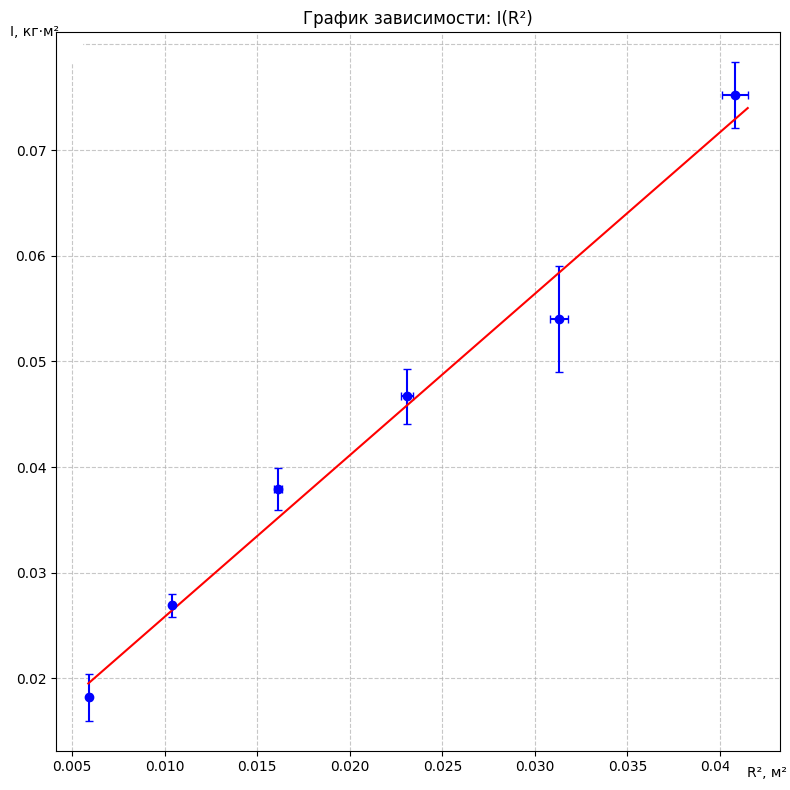

In [28]:
I_R = LinearMultipleMeasurement(list(indirect_R2.values()), list(indirect_I.values()))

I_R.a._delta_ /= 2
I_R.a._epsilon_ /= 2
I_R.a._round()

Drawer().plot_MKN(I_R,
    x_name='R²', x_unit='м²', y_name='I', y_unit='кг⋅м²',
    error_X=True, error_Y=True)

print(I_R.info)
I_0 = I_R.a
m_ut = I_R.b / 4
print(m_ut)

In [29]:
m_ut.naming('m_\\text{ут}', '\\text{кг}')
I_0.naming('I_0', '\\text{кг} \\cdot \\text{м}^2')
print(m_ut.meas_latex())
print(I_0.meas_latex())

AttributeError: 'Measurement' object has no attribute '_char'

- Вывод, контрольные вопросы